In [1]:
from cellmender.simulation import simulate_cells
from cellmender.simulation import simple_simulation
import cellmender.utils as cm_utils
from cellmender import denoise_count_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

cellmender_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellmender_dir, "notebooks", "output", "debug_sim")

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
%matplotlib widget

In [3]:
data = simulate_cells(G=2000)
print(data)

AnnData object with n_obs × n_vars = 1000 × 2000
    obs: 'cellid', 'celltype', 'is_empty', 'ambient_fraction', 'lib_size'
    var: 'ambient_profile', 'is_marker'
    uns: 'simulation_params', 'marker_sets', 'type_profiles'
    layers: 'noise', 'real'


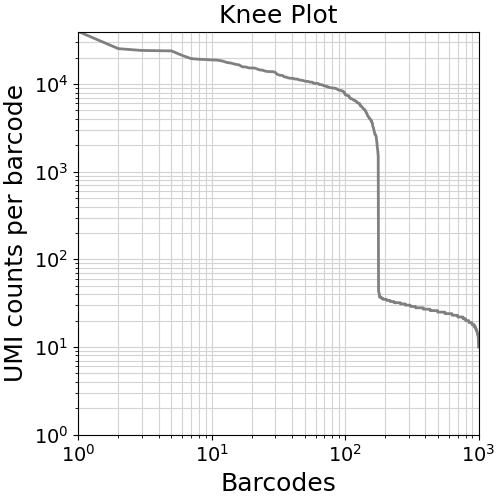

In [4]:
cm_utils.knee_plot(data)

In [5]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellmender.log")
denoised_data = denoise_count_matrix(data, max_iter=300, init_alpha=0.1, dirichlet_lambda=0.1, freeze_ambient_profile=False, beta=0.1, verbose=2, adata_out = adata_cellmender_path, log_file = adata_log_path, debug=True)

15:50:43 - INFO - Inferring celltype profiles.
15:50:43 - INFO - Number of parameters in the cellmender model: 10,891 (u: 5, beta: 1, gamma_type: 885, p_k: 10,000)
15:50:43 - INFO - Inferring the gene ambient profile from cell-types
15:50:43 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
15:50:43 - INFO - Performing Sparse EM with 1 Numba thread(s)


Logging to /Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/cellmender.log


15:50:44 - INFO - EM Iter   1: ll=-11564077.235 min_alpha=0.0705 mean_alpha=0.0838 median_alpha=0.0840 max_alpha=0.0898 beta=0.086672
15:50:44 - INFO - EM Iter   2: ll=-11540926.386 min_alpha=0.0545 mean_alpha=0.0749 median_alpha=0.0753 max_alpha=0.0864 beta=0.079191
15:50:44 - INFO - EM Iter   3: ll=-11536678.388 min_alpha=0.0439 mean_alpha=0.0689 median_alpha=0.0694 max_alpha=0.0853 beta=0.073848
15:50:44 - INFO - EM Iter   4: ll=-11534807.758 min_alpha=0.0355 mean_alpha=0.0643 median_alpha=0.0648 max_alpha=0.0850 beta=0.069592
15:50:44 - INFO - EM Iter   5: ll=-11533659.418 min_alpha=0.0293 mean_alpha=0.0606 median_alpha=0.0609 max_alpha=0.0849 beta=0.066013
15:50:44 - INFO - EM Iter   6: ll=-11532834.369 min_alpha=0.0245 mean_alpha=0.0574 median_alpha=0.0577 max_alpha=0.0850 beta=0.062905
15:50:44 - INFO - EM Iter   7: ll=-11532191.417 min_alpha=0.0208 mean_alpha=0.0547 median_alpha=0.0550 max_alpha=0.0851 beta=0.060151
15:50:44 - INFO - EM Iter   8: ll=-11531666.577 min_alpha=0.01

15:50:45 - INFO - Saving inferred adata to '/Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/adata_cellmender.h5ad'


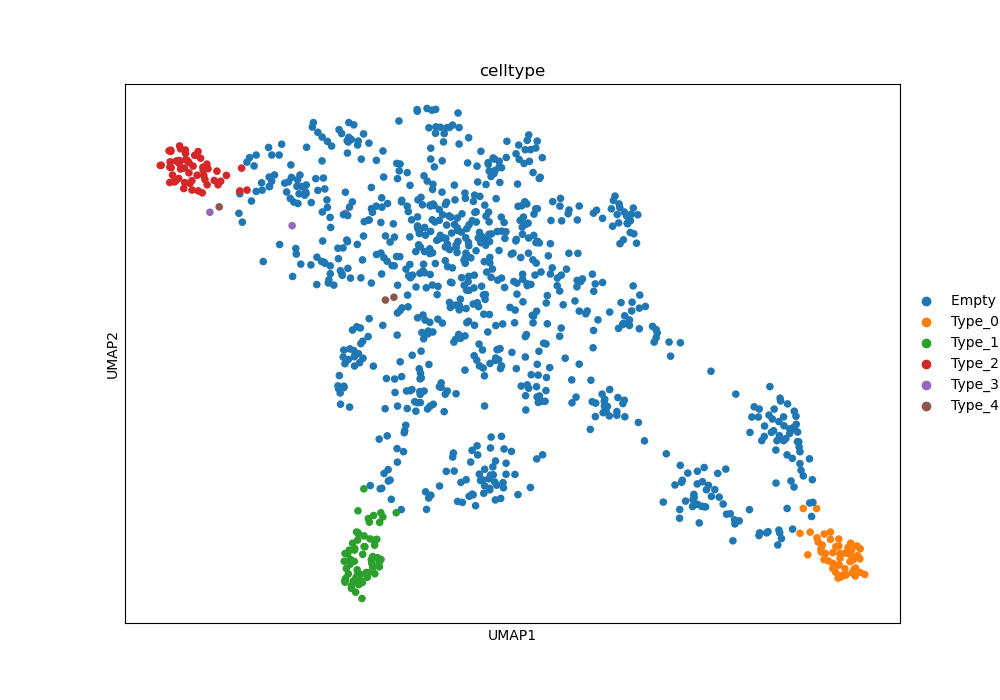

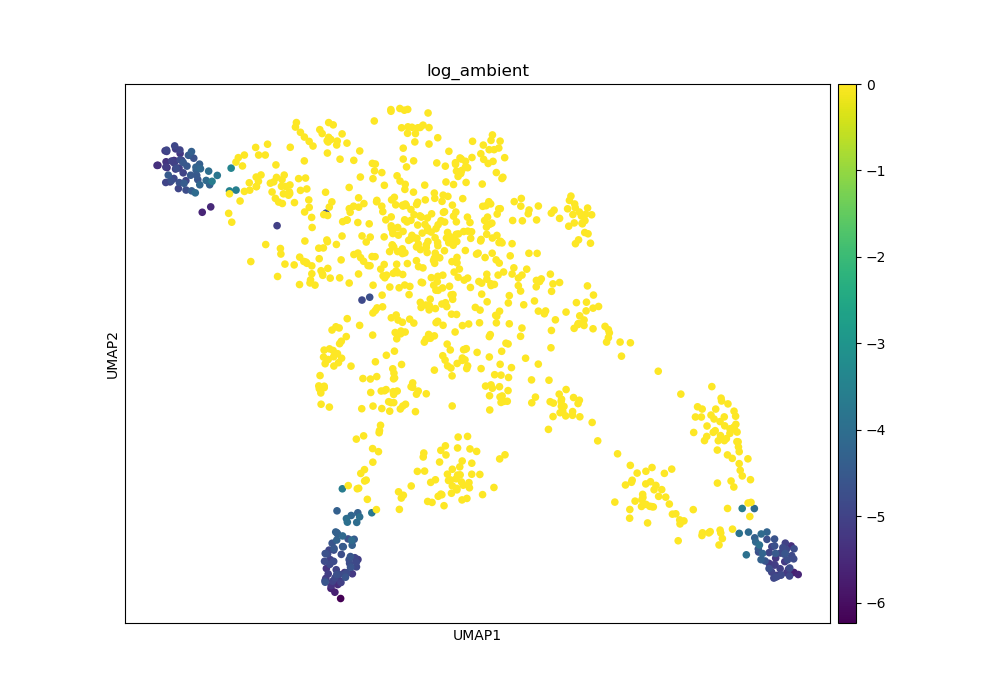

In [6]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction'])
sc.pl.umap(data, color='log_ambient', ax=ax)

In [7]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

          cellid celltype  is_empty  ambient_fraction      lib_size  \
Cell_1         1   Type_0     False          0.011010   7365.412534   
Cell_6         3   Type_2     False          0.014919   6909.402278   
Cell_14        1   Type_0     False          0.006082  15037.749495   
Cell_27        1   Type_0     False          0.007828  11163.441260   
Cell_40        1   Type_0     False          0.020484   3595.373852   
...          ...      ...       ...               ...           ...   
Cell_979       2   Type_1     False          0.001963  41953.688711   
Cell_989       3   Type_2     False          0.011697   7727.134061   
Cell_992       3   Type_2     False          0.008914   9101.610765   
Cell_996       1   Type_0     False          0.020059   5271.483406   
Cell_999       2   Type_1     False          0.006763  10717.958881   

          cell_ambient_fraction  alpha_hat  z_hat  
Cell_1                      0.1   0.021598      1  
Cell_6                      0.1   0.025842 

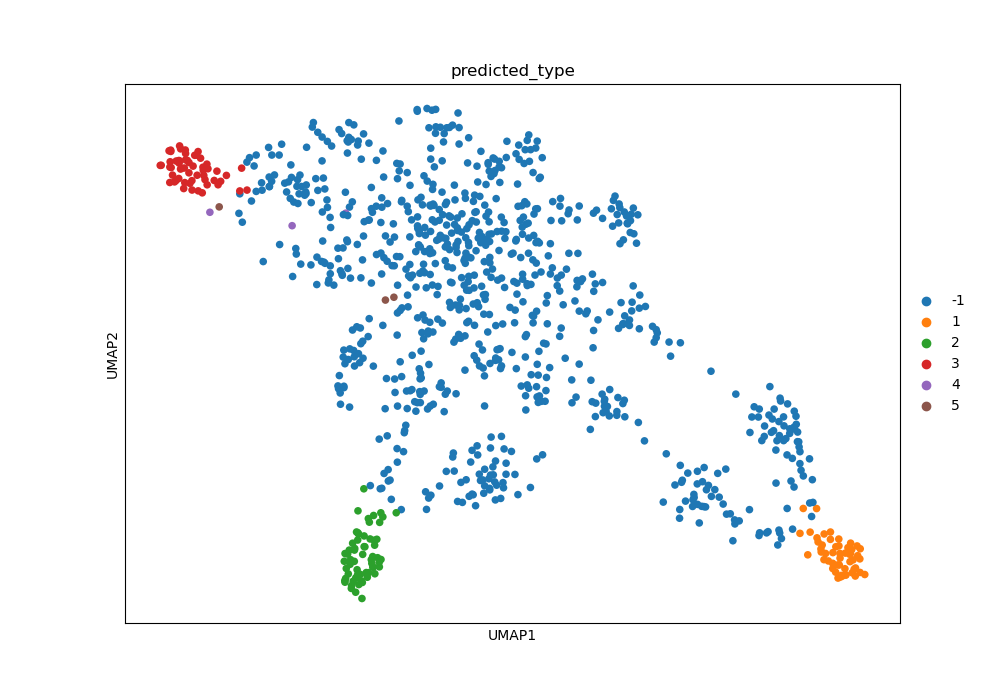

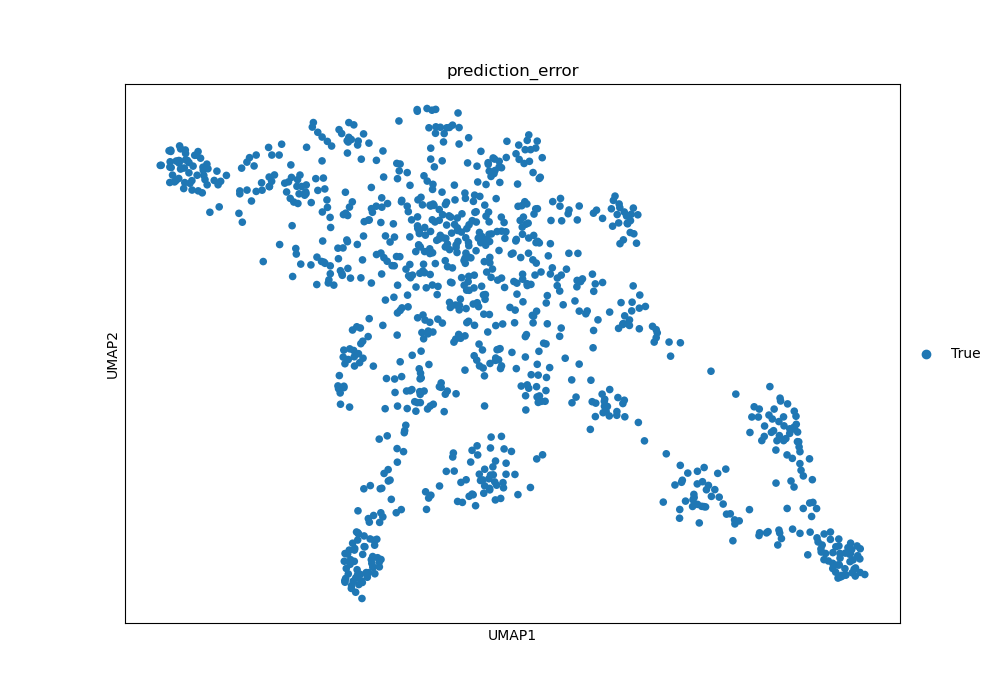

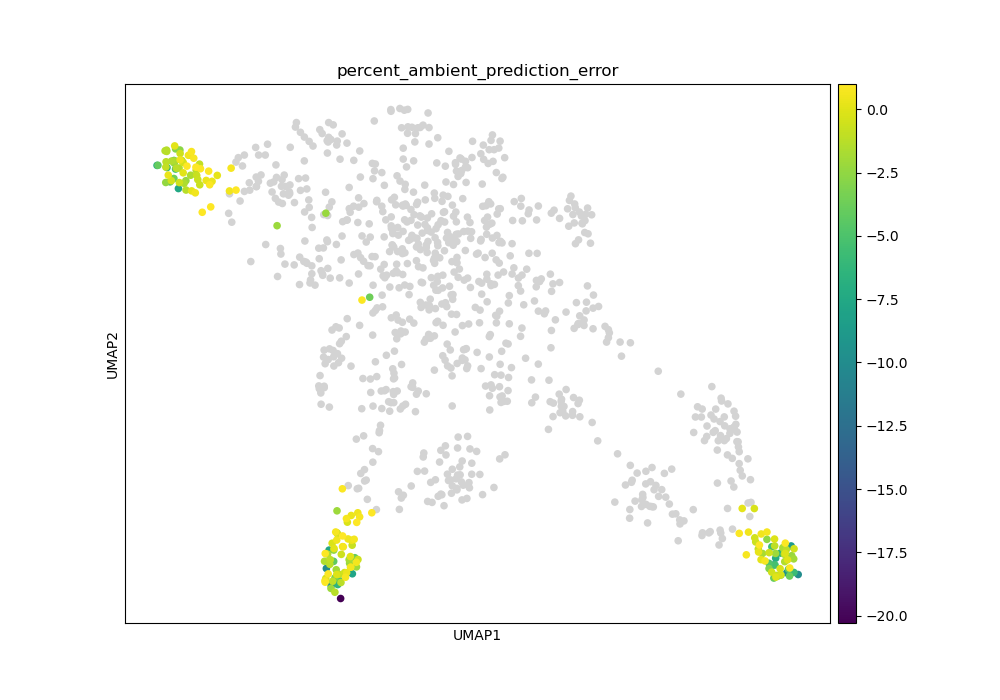

In [8]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'].astype(int) == denoised_data.obs['cellid'].astype(int))

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)